# Results

---
## Section 1 - Imports & General Setup

In [1]:
from typing import Dict, Any, List, Optional
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import sys

sys.path.append('src')

from tiny_hanabi.game.assemblers import get_game, normalize_payoffs
from tiny_hanabi.game.payoff_matrices import OPTIMAL_RETURNS, GameNames

from agents import *
from tiny_game import *
from config import *

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = [12, 7]
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- PATHS ---
RESULTS_BASE_DIR = "Results"
WORLD_MODEL_DIR  = os.path.join(RESULTS_BASE_DIR, "WorldModels")
PLOT_DIR         = "Plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# --- GAME NAMES ---
GAMES = ["A", "B", "C", "D", "E", "F", "G"]

# --- AGENT LABELS ---
BASELINE_AGENT_NAMES = ["IQ Learning", "VDN", "PBDP"]
TOM_AGENT_NAME       = "ToM PBVI"
MODEL_FREE_NAMES     = ["IQ Learning", "VDN"]
MODEL_BASED_NAMES    = ["PBDP"]

# --- CONSISTENT COLOURS ACROSS ALL PLOTS ---
AGENT_COLORS = {
    "IQ Learning"       : "#1f77b4",  # blue
    "VDN"               : "#ff7f0e",  # orange
    "PBDP"              : "#2ca02c",  # green
    "JESP"              : "#d62728",  # red
    "ToM PBVI"          : "#8c564b",  # brown
    "ToM PBVI (cross)"  : "#c5b0d5",  # light purple (mixed-ens cross-play)
    "ToM PBVI (spc)"    : "#5c2d91",  # dark purple (spec-ens cross-play)
    "Optimal"           : "#7f7f7f",  # grey
}

# --- ENVIRONMENTS ---
ENVIRONMENTS = {g: get_game_Rework(GameNames(g), normalize=True) for g in GAMES}


In [2]:
def load_results_csv(agent_name: str) -> pd.DataFrame:
    """Load final_results.csv for a given agent."""
    folder   = os.path.join(RESULTS_BASE_DIR, agent_name.replace(" ", "_"))
    csv_path = os.path.join(folder, "final_results.csv")
    df = pd.read_csv(csv_path)
    print(f"Loaded {agent_name}: {len(df)} rows, cols: {list(df.columns[:6])} ...")
    return df


def moving_average(series: pd.Series, window: int) -> pd.Series:
    """Centered moving average; preserves series length."""
    return series.rolling(window=window, min_periods=1, center=True).mean()


# Load all baseline CSVs
results_dict: Dict[str, pd.DataFrame] = {}
for _name in BASELINE_AGENT_NAMES:
    results_dict[_name] = load_results_csv(_name)

# Load ToM CSV
results_tom = load_results_csv(TOM_AGENT_NAME)

Loaded IQ Learning: 100000 rows, cols: ['reward_A', 'loss_A', 'reward_B', 'loss_B', 'reward_C', 'loss_C'] ...
Loaded VDN: 100000 rows, cols: ['reward_A', 'loss_A', 'reward_B', 'loss_B', 'reward_C', 'loss_C'] ...
Loaded PBDP: 1 rows, cols: ['reward_A', 'loss_A', 'reward_B', 'loss_B', 'reward_C', 'loss_C'] ...
Loaded ToM PBVI: 2 rows, cols: ['reward_A', 'reward_A_p0', 'reward_A_p1', 'loss_A', 'reward_B', 'reward_B_p0'] ...


---
## Section 2 - Baseline Analysis: Performance Graphs

In [3]:
# ============================================================
#  USER-CONFIGURABLE PARAMETERS
# ============================================================
avg_window  = 100     # Moving-average window (episodes) for model-free curves
max_episode = 10_000  # Maximum episode number shown on the x-axis
# ============================================================

Saved → Plots\baselines_all_games.png


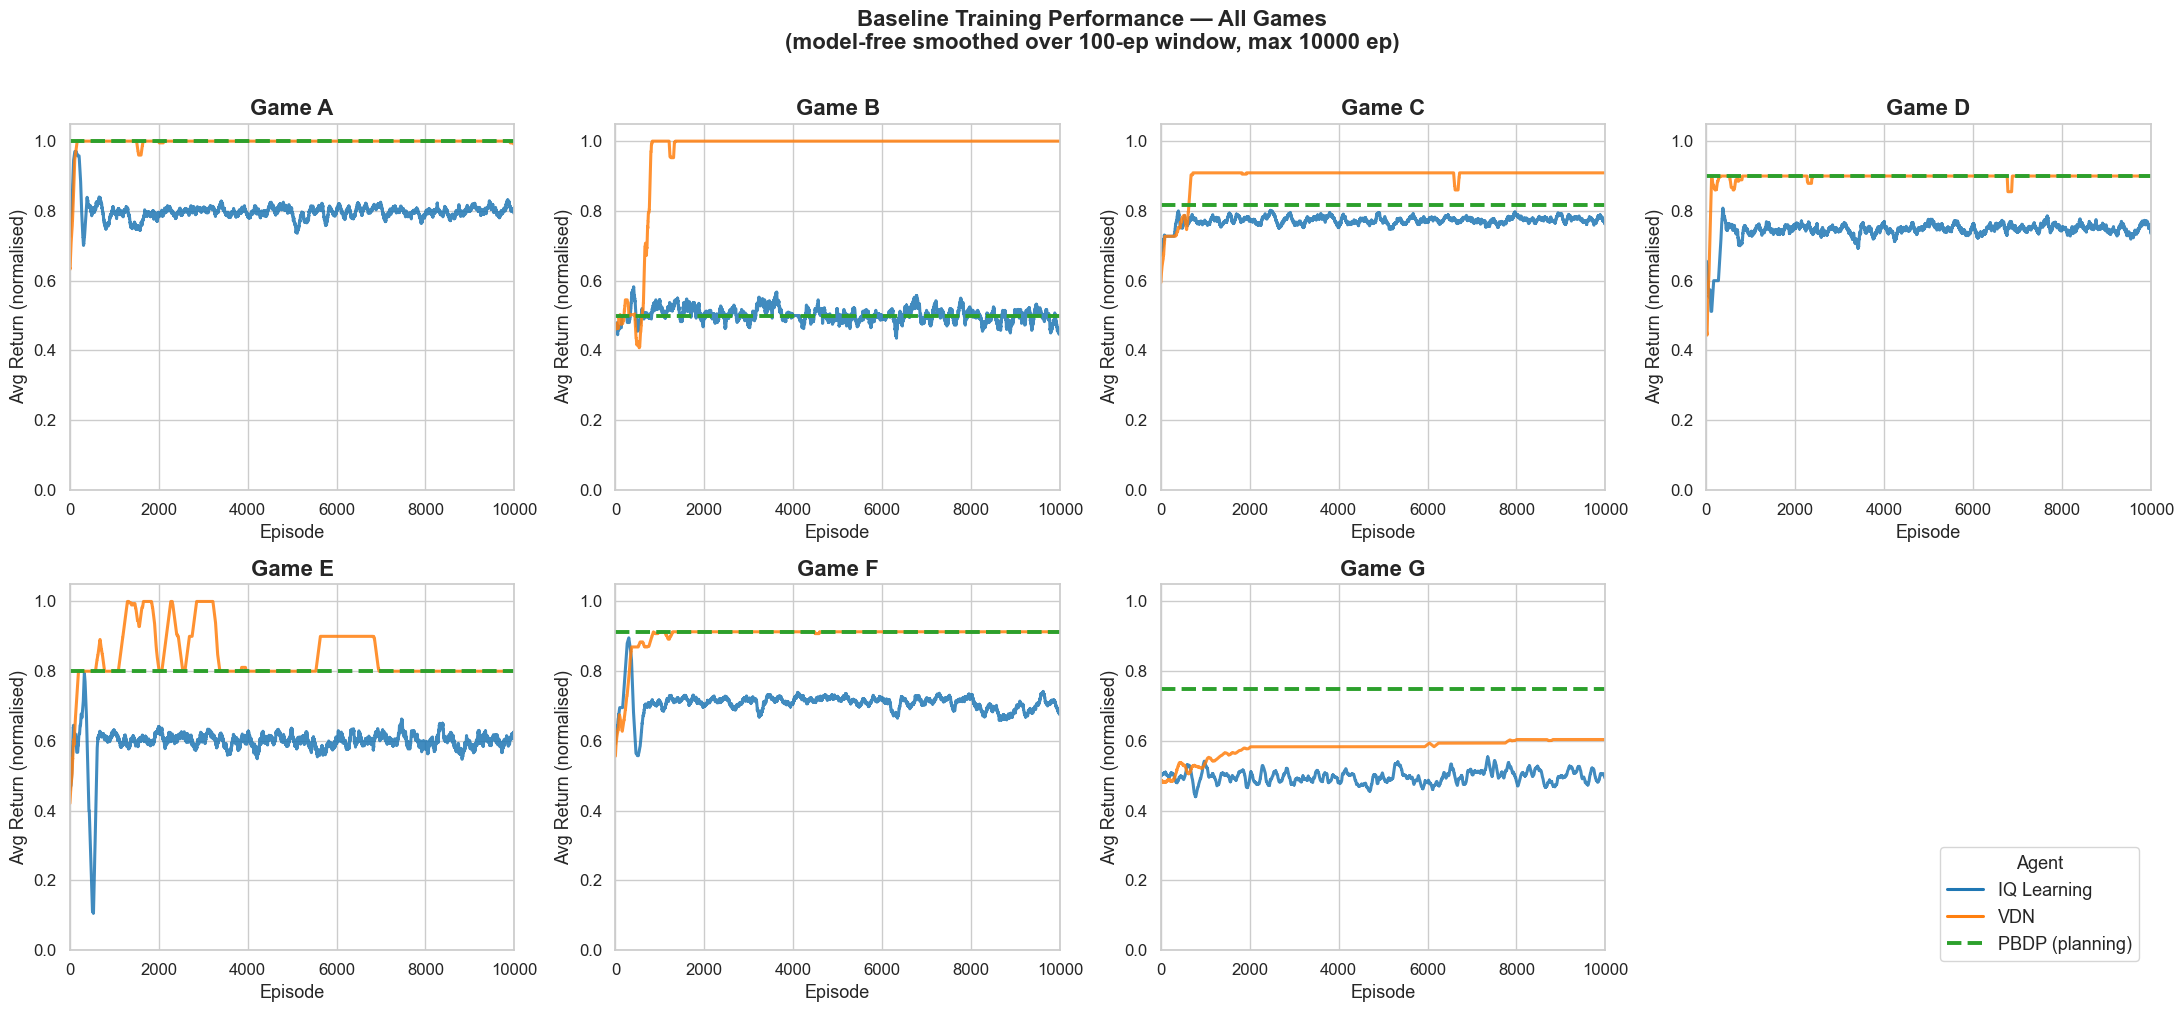

In [4]:
NCOLS, NROWS = 4, 2
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(22, 10))
axes_flat  = axes.flatten()

for idx, game in enumerate(GAMES):
    ax = axes_flat[idx]

    # Model-free: apply moving average and truncate
    for name in MODEL_FREE_NAMES:
        series   = results_dict[name][f"reward_{game}"].dropna().iloc[:max_episode]
        smoothed = moving_average(series, avg_window)
        ax.plot(np.arange(len(smoothed)), smoothed,
                label=name, color=AGENT_COLORS[name], linewidth=2.2, alpha=0.85)

    # Model-based: horizontal dashed line at converged value
    for name in MODEL_BASED_NAMES:
        final_val = results_dict[name][f"reward_{game}"].dropna().iloc[-1]
        ax.axhline(y=final_val, linestyle="--", linewidth=2.8,
                   color=AGENT_COLORS[name], label=name)

    ax.set_title(f"Game {game}", fontweight="bold", fontsize=16)
    ax.set_xlabel("Episode", fontsize=13)
    ax.set_ylabel("Avg Return (normalised)", fontsize=13)
    ax.tick_params(axis="both", labelsize=12)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlim(0, max_episode)

# Last subplot cell - shared legend
ax_legend = axes_flat[7]
ax_legend.set_visible(False)

legend_handles = [
    mlines.Line2D([], [], color=AGENT_COLORS[n], linewidth=2.2, label=n)
    for n in MODEL_FREE_NAMES
] + [
    mlines.Line2D([], [], color=AGENT_COLORS[n], linewidth=2.8,
                  linestyle="--", label=f"{n} (planning)")
    for n in MODEL_BASED_NAMES
]

fig.legend(handles=legend_handles, loc="lower right", bbox_to_anchor=(0.98, 0.05),
           frameon=True, fontsize=13, title="Agent", title_fontsize=13)

fig.suptitle(
    f"Baseline Training Performance \u2014 All Games\n"
    f"(model-free smoothed over {avg_window}-ep window, max {max_episode} ep)",
    fontsize=16, fontweight="bold", y=1.01
)
fig.tight_layout()

plot_path = os.path.join(PLOT_DIR, "baselines_all_games.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved \u2192 {plot_path}")
plt.show()


In [5]:
# Summary table: rows = agents, cols = games
summary_rows = {}
for name in BASELINE_AGENT_NAMES:
    row = {}
    for game in GAMES:
        series = results_dict[name][f"reward_{game}"].dropna()
        # Model-free: mean of last 1000 eps (converged region)
        # Model-based: final iteration value
        row[f"Game {game}"] = series.iloc[-1000:].mean() if name in MODEL_FREE_NAMES else series.iloc[-1]
    summary_rows[name] = row

summary_df = pd.DataFrame(summary_rows).T
summary_df.index.name = "Agent"

display(summary_df.style     .format("{:.4f}")     .highlight_max(axis=0, color="lightgreen")     .set_caption("Final Normalised Return \u2014 Baseline Agents"))

# LaTeX table (no colours)
print("\n=== LaTeX Table ===")
latex_str = summary_df.to_latex(
    float_format="{:.4f}".format,
    caption="Final normalised return of baseline agents across all games.",
    label="tab:baseline_results",
    bold_rows=False,
    escape=True,
)
print(latex_str)


,Game A,Game B,Game C,Game D,Game E,Game F,Game G
Agent,,,,,,,
IQ Learning,0.8012,0.4985,0.7683,0.7492,0.6095,0.7110,0.4971
VDN,1.0000,1.0000,0.9040,0.9000,0.8000,0.9130,0.6042
PBDP,1.0000,0.5000,0.8182,0.9000,0.8000,0.9130,0.7500



=== LaTeX Table ===
\begin{table}
\caption{Final normalised return of baseline agents across all games.}
\label{tab:baseline_results}
\begin{tabular}{lrrrrrrr}
\toprule
 & Game A & Game B & Game C & Game D & Game E & Game F & Game G \\
Agent &  &  &  &  &  &  &  \\
\midrule
IQ Learning & 0.8012 & 0.4985 & 0.7683 & 0.7492 & 0.6095 & 0.7110 & 0.4971 \\
VDN & 1.0000 & 1.0000 & 0.9040 & 0.9000 & 0.8000 & 0.9130 & 0.6042 \\
PBDP & 1.0000 & 0.5000 & 0.8182 & 0.9000 & 0.8000 & 0.9130 & 0.7500 \\
\bottomrule
\end{tabular}
\end{table}



---
## Section 3 - World Model: Training & Accuracy

Saved → Plots\section3_wm_training_loss.png


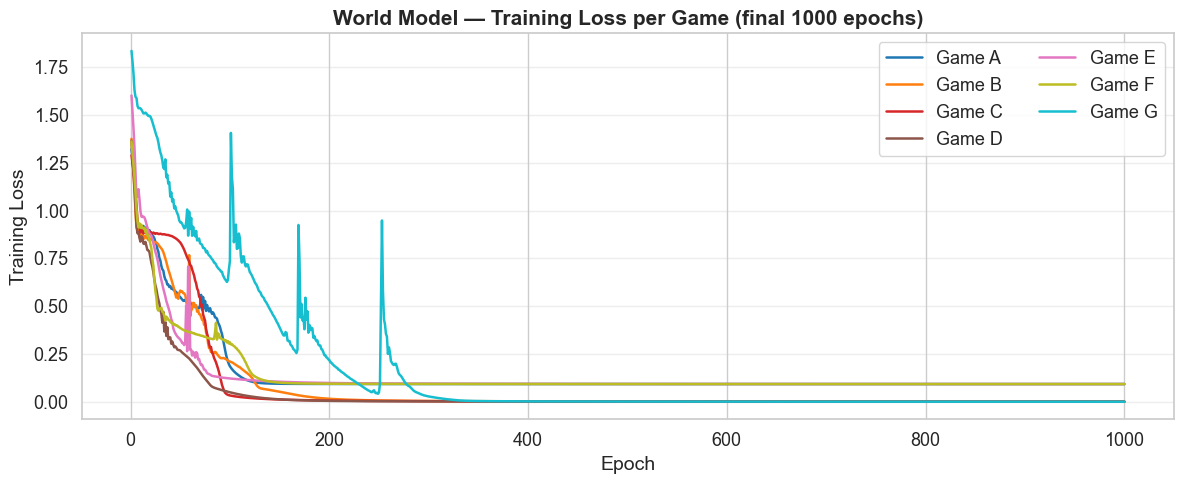

In [6]:
# --- 3.1  World Model --- Training Loss Curves ---
# One line per game over the 1000 final training epochs.

wm_df = pd.read_csv(os.path.join(WORLD_MODEL_DIR, "final_results.csv"))

GAME_COLORS = plt.cm.tab10(np.linspace(0, 1, len(GAMES)))

fig, ax = plt.subplots(figsize=(12, 5))
for i, game in enumerate(GAMES):
    epochs = np.arange(1, len(wm_df) + 1)
    ax.plot(epochs, wm_df[f"loss_{game}"],
            label=f"Game {game}", color=GAME_COLORS[i], linewidth=1.8)

ax.set_xlabel("Epoch", fontsize=14)
ax.set_ylabel("Training Loss", fontsize=14)
ax.set_title("World Model \u2014 Training Loss per Game (final 1000 epochs)",
             fontweight="bold", fontsize=15)
ax.tick_params(axis="both", labelsize=13)
ax.legend(fontsize=13, ncol=2)
ax.yaxis.grid(True, alpha=0.35)

fig.tight_layout()
plot_path = os.path.join(PLOT_DIR, "section3_wm_training_loss.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved \u2192 {plot_path}")
plt.show()


Saved → Plots\section3_wm_act_accuracy_over_epochs.png


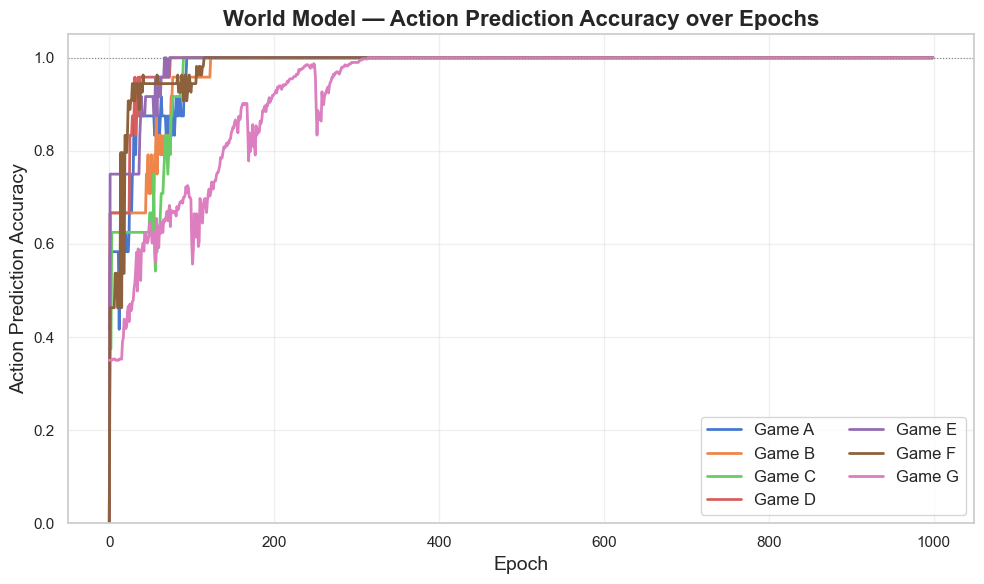

In [7]:
# --- 3.2 World Model --- Action Prediction Accuracy over Epochs ---

wm_df = pd.read_csv(os.path.join(WORLD_MODEL_DIR, "final_results.csv"))

plt.figure(figsize=(10, 6))

# Plot one line per game
for g in GAMES:
    plt.plot(
        wm_df.index,                      # epochs (row index)
        wm_df[f"act_acc_{g}"],            # action accuracy per game
        label=f"Game {g}",
        linewidth=2
    )

# Styling
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Action Prediction Accuracy", fontsize=14)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.axhline(1.0, color="grey", linewidth=0.8, linestyle=":")

plt.title("World Model — Action Prediction Accuracy over Epochs",
          fontweight="bold", fontsize=16)

plt.legend(fontsize=12, ncol=2)
plt.tight_layout()

# Save
plot_path = os.path.join(PLOT_DIR, "section3_wm_act_accuracy_over_epochs.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved → {plot_path}")

plt.show()

---
## Section 4 - ToM Performance Analysis

In [8]:
import torch
from runner import test_on_all_start_states
from train_worldmodel import setup_baseline_agents
from train_test_tom import load_all_world_models, load_ensembles, load_specialized_ensembles

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# 1. Baseline agents
print("Loading baseline agents...")
baseline_agents_by_game = setup_baseline_agents(ENVIRONMENTS)

# 2. World models
print("Loading world models...")
world_models_by_game = load_all_world_models(device, ENVIRONMENTS)

# 3. Mixed ensembles
print("Loading mixed ensembles...")
ensembles = load_ensembles()

# 4. Specialized ensembles
print("Loading specialized ensembles...")
specialized_ensembles = load_specialized_ensembles()

# 5. Build ToMBI agents and restore saved policies.
#    A single agent covers both player positions (policy trained for all private histories).
print("Loading ToMBI agents...")
TOM_DIR = os.path.join(RESULTS_BASE_DIR, "ToM_PBVI")
tom_agents_by_game = {}

for game_name in GAMES:
    env      = ENVIRONMENTS[game_name]
    wm, cfg  = world_models_by_game[game_name]
    ensemble = ensembles[game_name]
    agent = ToM_PBVI_Agent(
        env=env, num_cards=env.num_cards, num_actions=env.num_actions,
        world_model=wm, world_model_config=cfg, ensemble=ensemble,
        device=device, gamma=0.99,
    )
    agent.load(os.path.join(TOM_DIR, f"G_{game_name}_agent.pkl"))
    # Reuse the same object in both player slots
    tom_agents_by_game[game_name] = AgentList([agent, agent])

# 6. Unified registry:
#    game -> agent_name -> (p0_agent, p1_agent)
#    "ToM PBVI"       uses the mixed ensemble (set at init, never changed by default)
#    "ToM PBVI (spc)" SHARES the same agent objects; the caller switches the
#    ensemble to the partner-type specialized ensemble before each evaluation.

TOM_SPC_NAME    = "ToM PBVI (spc)"
ALL_AGENT_NAMES = BASELINE_AGENT_NAMES + [TOM_AGENT_NAME, TOM_SPC_NAME]
# Derived automatically so SHORT_NAMES stays in sync with ALL_AGENT_NAMES
SHORT_NAMES     = [name.replace("IQ Learning", "IQL") for name in BASELINE_AGENT_NAMES] + ["ToM PBVI", "ToM PBVI†"]

agents_registry = {}
for game_name in GAMES:
    agents_registry[game_name] = {}
    for name in BASELINE_AGENT_NAMES:
        al = baseline_agents_by_game[game_name][name]
        agents_registry[game_name][name] = (al[0], al[1])
    tom = tom_agents_by_game[game_name]
    agents_registry[game_name][TOM_AGENT_NAME] = (tom[0], tom[1])
    agents_registry[game_name][TOM_SPC_NAME]   = (tom[0], tom[1])

print("All agents loaded successfully.")
print(f"Agent names ({len(ALL_AGENT_NAMES)}): {ALL_AGENT_NAMES}")
print(f"Short names ({len(SHORT_NAMES)}):  {SHORT_NAMES}")


def cross_play_reward(env, p0_agent, p1_agent) -> float:
    """Average normalised return for a (P0, P1) pair over all start states."""
    return test_on_all_start_states(env, AgentList([p0_agent, p1_agent]))


Device: cuda
Loading baseline agents...
Loading Baseline Agents


Loading world models...

Loading all World Models...
Finished loading World Models.
Loading mixed ensembles...
Loading specialized ensembles...
Loading ToMBI agents...


All agents loaded successfully.
Agent names (5): ['IQ Learning', 'VDN', 'PBDP', 'ToM PBVI', 'ToM PBVI (spc)']
Short names (5):  ['IQL', 'VDN', 'PBDP', 'ToM PBVI', 'ToM PBVI†']


In [9]:
# --- 4.1  Overall Final Performance --- All Agents and Games ---
# Bars per game cluster:
#   Baselines (3)  : IQ Learning, VDN, PBDP
#   ToMBI self-play: both agents are ToMBI (mixed ensemble)
#   ToMBI cross (mixed ens.) : ToMBI paired with each baseline, mixed ensemble
#   ToMBI cross (spec. ens.) : ToMBI paired with each baseline, partner-specific ensemble
# Dotted grey line = normalised optimal return where available.

ALL_CSV_DATA = {
    "IQ Learning" : results_dict["IQ Learning"],
    "VDN"       : results_dict["VDN"],
    "PBDP"        : results_dict["PBDP"],
    "ToM PBVI"      : results_tom,
}

def final_perf(df, game, name):
    series = df[f"reward_{game}"].dropna()
    return series.iloc[-1000:].mean() if name in MODEL_FREE_NAMES else series.iloc[-1]

perf = {name: [final_perf(df, g, name) for g in GAMES]
        for name, df in ALL_CSV_DATA.items()}

# --- Cross-play: mixed ensemble --------------------------------------------------
print("Computing ToMBI cross-play averages (mixed ensemble)...")
tom_crossplay_mixed = []
for game_name in GAMES:
    env = ENVIRONMENTS[game_name]
    tom_p0, tom_p1 = agents_registry[game_name][TOM_AGENT_NAME]
    tom_p0.set_ensemble(ensembles[game_name])
    tom_p1.set_ensemble(ensembles[game_name])
    total, count = 0.0, 0
    for bl_name in BASELINE_AGENT_NAMES:
        bl_p0, bl_p1 = agents_registry[game_name][bl_name]
        total += cross_play_reward(env, tom_p0, bl_p1)   # ToM as P0
        total += cross_play_reward(env, bl_p0, tom_p1)   # ToM as P1
        count += 2
    tom_crossplay_mixed.append(total / count)
    print(f"  Game {game_name}: mixed cross-play = {tom_crossplay_mixed[-1]:.3f}")

# --- Cross-play: specialized ensemble --------------------------------------------
print("Computing ToMBI cross-play averages (specialized ensemble)...")
tom_crossplay_spc = []
for game_name in GAMES:
    env     = ENVIRONMENTS[game_name]
    tom_p0, tom_p1 = agents_registry[game_name][TOM_AGENT_NAME]
    mixed   = ensembles[game_name]
    total, count = 0.0, 0
    for bl_name in BASELINE_AGENT_NAMES:
        bl_p0, bl_p1 = agents_registry[game_name][bl_name]
        spc = specialized_ensembles[game_name].get(bl_name, mixed)
        tom_p0.set_ensemble(spc)
        total += cross_play_reward(env, tom_p0, bl_p1)   # ToM as P0
        tom_p1.set_ensemble(spc)
        total += cross_play_reward(env, bl_p0, tom_p1)   # ToM as P1
        count += 2
    # Reset to mixed
    tom_p0.set_ensemble(mixed)
    tom_p1.set_ensemble(mixed)
    tom_crossplay_spc.append(total / count)
    print(f"  Game {game_name}: spec. cross-play = {tom_crossplay_spc[-1]:.3f}")

# --- Normalised optimal returns --------------------------------------------------
optimal_vals = {}
for game in GAMES:
    try:
        optimal_vals[game] = OPTIMAL_RETURNS.get(GameNames(game))
    except Exception:
        optimal_vals[game] = None

# --- Bar layout: 5 baselines + 3 ToMBI variants = 8 bars per cluster ------------
BAR_NAMES  = BASELINE_AGENT_NAMES + ["ToM PBVI", "ToM PBVI (cross)", "ToM PBVI (spc)"]
BAR_VALUES = {name: perf[name] for name in BASELINE_AGENT_NAMES}
BAR_VALUES["ToM PBVI"]         = perf["ToM PBVI"]
BAR_VALUES["ToM PBVI (cross)"] = tom_crossplay_mixed
BAR_VALUES["ToM PBVI (spc)"]   = tom_crossplay_spc

BAR_LABELS = {
    "ToM PBVI"        : "ToMBI (self-play)",
    "ToM PBVI (cross)" : "ToMBI cross (mixed ens.)",
    "ToM PBVI (spc)"   : "ToMBI cross (spec. ens.)",
}

BAR_HATCHES = {
    "ToM PBVI (cross)" : "//",
    "ToM PBVI (spc)"   : "xx",
}

n_bars  = len(BAR_NAMES)
x       = np.arange(len(GAMES))
width   = 0.10
offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * width

fig, ax = plt.subplots(figsize=(24, 6))

for i, name in enumerate(BAR_NAMES):
    hatch = BAR_HATCHES.get(name)
    label = BAR_LABELS.get(name, name)
    ax.bar(x + offsets[i], BAR_VALUES[name], width,
           label=label, color=AGENT_COLORS[name],
           hatch=hatch, alpha=0.85, zorder=3, edgecolor="white")

# Optimal return markers
for j, game in enumerate(GAMES):
    opt = optimal_vals.get(game)
    if opt is not None:
        ax.plot([j - 0.45, j + 0.45], [opt, opt],
                color=AGENT_COLORS["Optimal"], linewidth=1.8, linestyle=":", zorder=5)

ax.set_xticks(x)
ax.set_xticklabels([f"Game {g}" for g in GAMES], fontsize=14)
ax.set_ylabel("Final Normalised Return", fontsize=14)
ax.set_ylim(0, 1.15)
ax.set_title("Overall Final Performance \u2014 All Agents & Games",
             fontweight="bold", fontsize=16)
ax.tick_params(axis="both", labelsize=13)
ax.yaxis.grid(True, alpha=0.35, zorder=0)

opt_handle = mlines.Line2D([], [], color=AGENT_COLORS["Optimal"],
                           linestyle=":", linewidth=1.8, label="Optimal")
handles, labels_l = ax.get_legend_handles_labels()
ax.legend(handles + [opt_handle], labels_l + ["Optimal"],
          fontsize=12, loc="lower right", ncol=2)

fig.tight_layout()
plot_path = os.path.join(PLOT_DIR, "section4_overall_performance.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved \u2192 {plot_path}")
plt.show()


Computing ToMBI cross-play averages (mixed ensemble)...


AttributeError: 'ToM_PBVI_Agent' object has no attribute 'set_ensemble'

In [ ]:
# --- 4.2  Cross-Play Performance Matrix ---
# rows = P0 agent type, cols = P1 agent type
# value = avg normalised return when row-agent plays P0 and col-agent plays P1
# diagonal = self-play, off-diagonal = ad-hoc cross-play
#
# "ToMBI\u2020" row/col: same ToMBI agent but with the partner's specialized ensemble
# activated for each cell. For non-baseline partners (other ToMBI variants),
# the mixed ensemble is used as a fallback.

N = len(ALL_AGENT_NAMES)   # 7 (5 baselines + ToMBI + ToMBI\u2020)
crossplay_matrices = {}

print("Running cross-play evaluation...")
for game_name in GAMES:
    env     = ENVIRONMENTS[game_name]
    mixed   = ensembles[game_name]
    mat     = np.zeros((N, N))

    for i, p0_name in enumerate(ALL_AGENT_NAMES):
        for j, p1_name in enumerate(ALL_AGENT_NAMES):
            p0 = agents_registry[game_name][p0_name][0]
            p1 = agents_registry[game_name][p1_name][1]

            # -- Determine which specialized ensemble to use (if any) ----------
            # ToMBI (spc) as P0: use the specialized ensemble for the P1 type
            if p0_name == TOM_SPC_NAME:
                partner = p1_name if p1_name in BASELINE_AGENT_NAMES else None
                spc = specialized_ensembles[game_name].get(partner, mixed) if partner else mixed
                p0.set_ensemble(spc)

            # ToMBI (spc) as P1: use the specialized ensemble for the P0 type
            if p1_name == TOM_SPC_NAME:
                partner = p0_name if p0_name in BASELINE_AGENT_NAMES else None
                spc = specialized_ensembles[game_name].get(partner, mixed) if partner else mixed
                p1.set_ensemble(spc)

            mat[i, j] = cross_play_reward(env, p0, p1)

            # -- Reset ToMBI agents to mixed after every cell ------------------
            if p0_name in [TOM_AGENT_NAME, TOM_SPC_NAME]:
                p0.set_ensemble(mixed)
            if p1_name in [TOM_AGENT_NAME, TOM_SPC_NAME]:
                p1.set_ensemble(mixed)

    crossplay_matrices[game_name] = mat
    print(f"  Game {game_name} done")

# Plot: 7 games in a 2x4 grid; last cell = colorbar
fig, axes = plt.subplots(2, 4, figsize=(28, 13))
axes_flat = axes.flatten()
last_im   = None

for idx, game_name in enumerate(GAMES):
    ax  = axes_flat[idx]
    mat = crossplay_matrices[game_name]

    im = ax.imshow(mat, vmin=0.0, vmax=1.0, cmap="RdYlGn", aspect="auto")
    last_im = im

    ax.set_xticks(range(N))
    ax.set_xticklabels(SHORT_NAMES, fontsize=11, rotation=35, ha="right", fontweight="bold")
    ax.set_yticks(range(N))
    ax.set_yticklabels(SHORT_NAMES, fontsize=11, fontweight="bold")
    ax.set_xlabel("P1 (partner)", fontsize=13)
    ax.set_ylabel("P0 (self)",    fontsize=13)
    ax.set_title(f"Game {game_name}", fontweight="bold", fontsize=15)

    # Draw a separator line before the last two rows/cols (ToMBI variants)
    ax.axhline(N - 2 - 0.5, color="white", linewidth=1.5, linestyle="--")
    ax.axvline(N - 2 - 0.5, color="white", linewidth=1.5, linestyle="--")

    # Annotate cells
    for r in range(N):
        for c in range(N):
            val   = mat[r, c]
            color = "black" if 0.3 < val < 0.75 else "white"
            ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                    fontsize=9, color=color, fontweight="bold")

# Shared colorbar in the 8th slot
ax_cb = axes_flat[7]
ax_cb.axis("off")
cbar = fig.colorbar(last_im, ax=ax_cb, fraction=0.6, pad=0.05)
cbar.set_label("Avg Return (normalised)", fontsize=13)
cbar.ax.tick_params(labelsize=12)

fig.suptitle(
    "Cross-Play Performance Matrix \u2014 All Agent Pairings per Game\n"
    "(bold diagonal = self-play; ToMBI\u2020 uses partner-specific ensemble; dashed line separates ToMBI variants)",
    fontsize=15, fontweight="bold"
)
fig.tight_layout()

plot_path = os.path.join(PLOT_DIR, "section4_crossplay_matrix.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved \u2192 {plot_path}")
plt.show()


---
## Section 5 - Theory-of-Mind Behaviour Analysis

In [ ]:
# --- 5.1  Policy Comparison — Baseline Disagreement Detection ---
# For each private history we query every agent's greedy action.
# We flag only histories where the BASELINE agents disagree with each other.
# The ToM agent's choice is then investigated in those contested histories.

def format_obs(obs: tuple, env) -> str:
    """Human-readable string for a private observation tuple."""
    if isinstance(env, DecPOMDP):
        cards = obs[:2]
        acts  = obs[2:]
        cs  = "(" + ",".join("?" if c == -1 else str(c) for c in cards) + ")"
        as_ = "[" + ",".join(str(a) for a in acts) + "]" if acts else "[]"
        return f"cards{cs} acts{as_}"
    else:  # MyHanabi
        cards  = obs[:4]
        events = obs[4:]
        cs = "(" + ",".join("?" if c == -1 else str(c) for c in cards) + ")"
        ev = "[" + ",".join(str(e) for e in events) + "]" if events else "[]"
        return f"cards{cs} evts{ev}"


policy_rows_by_game: Dict[str, List[dict]] = {}

for game_name in GAMES:
    env  = ENVIRONMENTS[game_name]
    rows = []

    # Use the ToM agent's full history table (covers both player positions)
    tom_agent = agents_registry[game_name][TOM_AGENT_NAME][0]

    for obs, done, turn_id, _ in tom_agent.all_private_histories:
        if done:
            continue

        agents_at_turn = {name: agents_registry[game_name][name][turn_id]
                          for name in ALL_AGENT_NAMES}

        actions: Dict[str, int] = {}
        for name, agent in agents_at_turn.items():
            try:
                actions[name] = agent.act(obs, exploit=True)
            except Exception:
                actions[name] = -1

        # Disagreement among BASELINES only
        baseline_actions = [actions[n] for n in BASELINE_AGENT_NAMES if actions[n] != -1]
        baseline_disagree = len(set(baseline_actions)) > 1

        rows.append({
            "obs"              : obs,
            "obs_str"          : format_obs(obs, env),
            "turn"             : turn_id,
            "depth"            : len(obs),
            "baseline_disagree": baseline_disagree,
            **{name: actions[name] for name in ALL_AGENT_NAMES},
        })

    policy_rows_by_game[game_name] = rows
    n_contested = sum(r["baseline_disagree"] for r in rows)
    print(f"Game {game_name}: {len(rows)} histories | {n_contested} contested by baselines")
